# LLM Prompt Intent Clustering

**Objective:** Discover recurring prompt intents for routing, evaluation, and prompt-library design without labelled training data.

This notebook uses deterministic demo text so the entire unsupervised workflow remains executable offline. Generator topics are hidden from model fitting and used only for retrospective diagnostics.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo corpus


In [2]:
TOPICS = {
  "coding": [
    "python",
    "debug",
    "function",
    "api",
    "error",
    "repository",
    "test",
    "refactor"
  ],
  "analytics": [
    "dashboard",
    "metric",
    "sql",
    "trend",
    "segment",
    "table",
    "report",
    "insight"
  ],
  "writing": [
    "rewrite",
    "caption",
    "tone",
    "draft",
    "audience",
    "headline",
    "summary",
    "edit"
  ],
  "research": [
    "paper",
    "evidence",
    "source",
    "compare",
    "literature",
    "method",
    "citation",
    "finding"
  ]
}
ENTITY = "prompt"
COMMON_WORDS = ["customer", "system", "request", "team", "today", "information", "service", "workflow"]
rows = []
for topic, vocabulary in TOPICS.items():
    for row_id in range(75):
        tokens = rng.choice(vocabulary, size=7, replace=True).tolist()
        tokens += rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        if rng.random() < 0.45:
            other_topic = rng.choice([name for name in TOPICS if name != topic])
            tokens += rng.choice(TOPICS[other_topic], size=2, replace=True).tolist()
        rng.shuffle(tokens)
        rows.append({"text": " ".join(tokens), "generator_topic": topic, "record_id": f"{topic[:3]}-{row_id:03d}"})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Corpus: {len(data):,} {ENTITY} records")
display(data.head())
display(data["generator_topic"].value_counts().rename("records").to_frame())


Corpus: 300 prompt records


,text,generator_topic,record_id
0,draft today audience tone tone draft tone info...,writing,wri-053
1,workflow source service method source request ...,research,res-041
2,workflow rewrite python tone tone error headli...,writing,wri-002
3,request api customer api test refactor api tea...,coding,cod-009
4,information literature source request source r...,research,res-008


,records
generator_topic,
writing,75
research,75
coding,75
analytics,75


## 3. TF-IDF representation and cluster selection


In [3]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=500, sublinear_tf=True)
vectors = vectorizer.fit_transform(data["text"])
print(f"Vector matrix: {vectors.shape[0]} documents × {vectors.shape[1]} features")

selection_rows = []
for k in range(2, 7):
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(vectors)
    selection_rows.append({"k": k, "silhouette": silhouette_score(vectors, labels, metric="cosine"), "inertia": candidate.inertia_})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))

best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
model = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
data["cluster"] = model.fit_predict(vectors)
print(f"Selected k={best_k} from cosine silhouette; score={selection['silhouette'].max():.4f}")


Vector matrix: 300 documents × 500 features
Selected k=4 from cosine silhouette; score=0.1423


,k,silhouette,inertia
0,2,0.0788,264.2965
1,3,0.1108,252.2504
2,4,0.1423,240.6307
3,5,0.1179,238.1719
4,6,0.0922,236.0074


## 4. Interpret discovered clusters


In [4]:
terms = np.asarray(vectorizer.get_feature_names_out())
top_terms = []
for cluster_id, center in enumerate(model.cluster_centers_):
    words = terms[np.argsort(center)[-10:][::-1]]
    top_terms.append({"cluster": cluster_id, "records": int((data["cluster"] == cluster_id).sum()), "top_terms": ", ".join(words)})
display(pd.DataFrame(top_terms))
display(pd.crosstab(data["generator_topic"], data["cluster"], margins=True))
ari = adjusted_rand_score(data["generator_topic"], data["cluster"])
print(f"Retrospective ARI against hidden generator topics: {ari:.4f}")
print("The generator topic was not provided to TF-IDF or K-Means.")


Retrospective ARI against hidden generator topics: 1.0000
The generator topic was not provided to TF-IDF or K-Means.


,cluster,records,top_terms
0,0,75,"insight, report, metric, sql, dashboard, trend..."
1,1,75,"error, repository, api, debug, test, function,..."
2,2,75,"compare, source, literature, method, evidence,..."
3,3,75,"tone, caption, rewrite, audience, summary, hea..."


cluster,0,1,2,3,All
generator_topic,,,,,
analytics,75,0,0,0,75
coding,0,75,0,0,75
research,0,0,75,0,75
writing,0,0,0,75,75
All,75,75,75,75,300


## 5. Two-dimensional map and stability check


Cluster stability across two random seeds (ARI): 1.0000


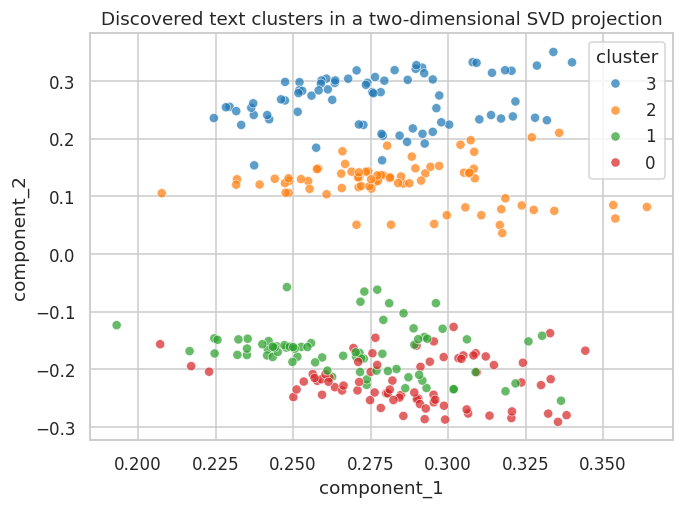

In [5]:
from sklearn.decomposition import TruncatedSVD

projection = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(vectors)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.72)
plt.title("Discovered text clusters in a two-dimensional SVD projection")
plt.tight_layout()
plt.show()

alternate = KMeans(n_clusters=best_k, n_init=30, random_state=7).fit_predict(vectors)
stability = adjusted_rand_score(data["cluster"], alternate)
print(f"Cluster stability across two random seeds (ARI): {stability:.4f}")


## 6. Assign new text and inspect nearest records


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

probe = " ".join(list(TOPICS.values())[0][:5])
probe_vector = vectorizer.transform([probe])
probe_cluster = int(model.predict(probe_vector)[0])
similarities = cosine_similarity(probe_vector, vectors).ravel()
nearest = np.argsort(similarities)[-5:][::-1]
print(f"Probe: {probe}")
print(f"Assigned cluster: {probe_cluster}")
display(data.loc[nearest, ["record_id", "text", "cluster"]].assign(cosine_similarity=similarities[nearest]).round(4))


Probe: python debug function api error
Assigned cluster: 1


,record_id,text,cluster,cosine_similarity
190,cod-061,workflow system function information python de...,1,0.4644
278,cod-048,debug function test customer debug function fu...,1,0.3460
281,cod-021,function information request table function re...,1,0.3387
139,cod-002,api system error api information test python d...,1,0.3362
68,cod-056,function system customer workflow python debug...,1,0.3313


## 7. Findings and limitations

- Cluster quality is evaluated with cohesion, stability, interpretable terms, and a hidden synthetic diagnostic.
- The synthetic corpus proves the workflow, not production accuracy.
- Production use should replace TF-IDF with validated domain embeddings when semantic nuance matters.
- Topics should be reviewed by domain experts before they drive routing or policy decisions.
